In [76]:
import os
import sys
import pickle
import pandas as pd
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F

this_path = os.path.abspath(os.getcwd())
datasets_dir = os.path.join(this_path, 'datasets')
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

import warnings
warnings.filterwarnings("ignore")
script_name_feature_extraction = source_path+"/scripts/deep_feature_extraction.py"
load_folder = os.path.join(datasets_dir, 'custom')
temp_save_folder = os.path.join(this_path, 'temp')
if not os.path.exists(temp_save_folder):
    os.makedirs(temp_save_folder)
temp_df_name = 'temp_df_w_patches.csv'

In [84]:
selected_model = 'clip-vit-large-patch14-inter'
verbose=False #if verbose the batch per batch extraction info is printed
selected_classification_head = 'MLPClassifier1' #'logreg' #'MLPClassifier2'#'MLPClassifier1'#'TransformerClassifier'#'1DCNNClassifier'#'MLPClassifier2'
kind = 'patches_224'  # Example kind, can be changed (if 'body' -> forces most probable metric)
calibrate=True
threshold=0.5
dataset = 'icdar' #determines which classification head is loaded, the one trained on icdar or IAM or else
selected_metric='majority_vote'

model_parameters = {
    'n_neurons':256,
    'hidden_sizes': [16],  # Hidden sizes for MLPClassifier2
    'dropout':0.9,
    'with_input_norm': 'batch_norm',  # Whether to use input normalization 'batch_norm' , None
    'mean': None,  # Mean for input normalization
    'scale': None,  # Scale for input normalization
    'activation': 'relu'
}

In [102]:
#get filenames in the load_folder 
subset = ['0008','0007'] #if empty all are selected
#get all filenames in the load_folder
filenames = os.listdir(load_folder)
#for each filename remove the extension, split at '_' and get the id (first element) and the label (last element)
ids_w_labels = {'writer': [], 'male': [],'file_name': []}
for f in filenames:
    name = os.path.splitext(f)[0]
    parts = name.split('_')
    id = parts[0]
    label = parts[-1]
    if subset and id not in subset:
        continue
    ids_w_labels['writer'].append(id)
    if label not in ['0', '1']:
        label = -1
    ids_w_labels['male'].append(int(label))
    ids_w_labels['file_name'].append(os.path.join(load_folder, f))
train_df = pd.DataFrame(ids_w_labels)
#add dummy variables for compatibility with existing functions
train_df['isEng'] = 0
train_df['same_text'] = 0
print(train_df)


  writer  male                                          file_name  isEng  \
0   0007     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
1   0008     1  c:\Users\andre\VsCode\PD related projects\gend...      0   

   same_text  
0          0  
1          0  


Some writers do not occur exactly 20 times.
writer
0007    20
0008    12
Name: count, dtype: int64
--------------------------------
  writer  male                                          file_name  isEng  \
0   0007     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
1   0008     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
0   0007     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
0   0007     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
1   0008     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
1   0008     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
0   0007     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
0   0007     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
0   0007     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
1   0008     1  c:\Users\andre\VsCode\PD related projects\gend...      0   
0   0007     1  c:\Users\andre\V

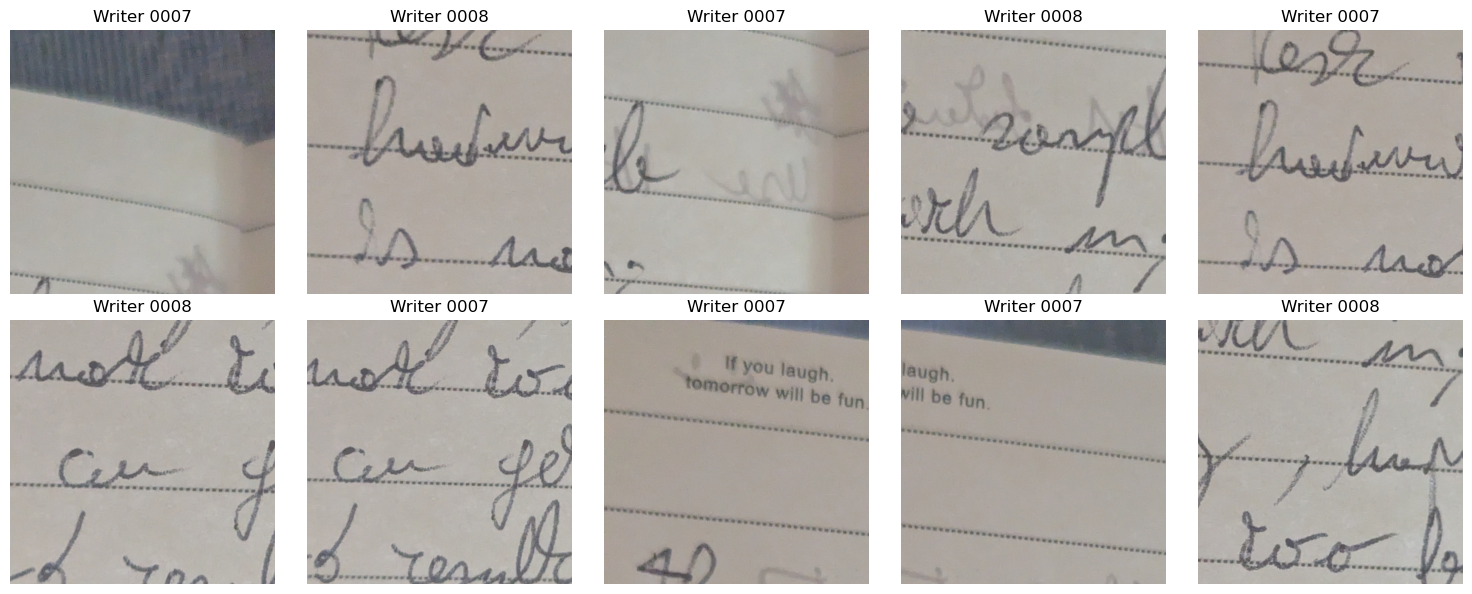

In [103]:
#prepare the df with the patches
from utils import tests

modality='final'#"final" #'patches'
dynamic=True #if True the resolution and stride are adjusted based on the image size
gw=3
prop=1
n_cc=1
resolution=224
stride=int(resolution/1.5)
sort_by="black_ratio"
#i select the m patches per file that have the highest number of cc
m = 20
if modality=="final":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_resolution, axis=1,args=(resolution,stride, n_cc, dynamic, gw)), []))
elif modality=="body":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_body, axis=1,args=()), []))
elif modality=="patches":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row, axis=1,args=(gw, n_cc,prop)), []))
train_df_expanded_sorted = train_df_expanded.sort_values(by=sort_by, ascending=False)
train_df_expanded = train_df_expanded_sorted.groupby('file_name').head(m)   # Select top m patches per page
tests.check_occurrences(train_df_expanded,count=m)
print("--------------------------------")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(train_df_expanded.head(20))
visualization.plot_cropped_sections(train_df_expanded)
#save to a temporary directory
train_df_expanded.to_csv(os.path.join(temp_save_folder, temp_df_name), index=False)

In [104]:
#extract representations for the patches
train_df = pd.read_csv(os.path.join(temp_save_folder, temp_df_name))

huggingface_parameter = global_vars.get_props(selected_model).hugging
outputs_dir = os.path.join(this_path, 'models', selected_model)
if not os.path.exists(outputs_dir):
    os.makedirs(outputs_dir)

extra_view=False
contrastive_mode = False  # Set to True for contrastive learning
custom_pretrained = 'original'  # 'original', 'contrastive', 'fine-tune'
data_augmentation = False  # Set to True for data augmentation

n_patches=-1 #with negative values all patches are considered
num_views = 1  # Number of views for data augmentation, set to 1 for no augmentation

args = script_launching.DotDict(
    N_max=282, #useless parameter in the script
    patches=True,
    input_filename=temp_df_name,
    huggingface=huggingface_parameter,
    pooling=False,  # if true in transformer models use pooling, if false only the cls token
    custom_transform=False,
    transform_mode='resize',
    save_h5=False,
    selected_model=selected_model,  # googlenet, alexnet
    truncation='remove head',
    running='new-laptop',
    saved='old-laptop',
    model_mode='truncated',  # 'truncation
    batching=True,
    batch_size=min(16, len(train_df_expanded)),#64
    select_cls=False,
    num_workers=2,#4
    pin_memory=True,
    show_image=False,  # Show the image with the extracted patches
    save_to_log=False,  # Save the extracted features to a log file
    data_augmentation=data_augmentation,
    num_views=num_views,  # Number of views for data augmentation
    save_dir=temp_save_folder,
    n_patches=n_patches,
    zarr_path = '',
    contrastive_mode=contrastive_mode,  # Set to True for contrastive learning
    augmentation_code = 'simple',
    custom_pretrained=custom_pretrained,
    verbose=verbose,
    train_df_path=os.path.join(temp_save_folder, temp_df_name),
    selected_dataset = 'lazy'
    #script_mode='standalone'
)
script_launching.run_experiment_threaded(args,script_name_feature_extraction)  # Test a single run first

Starting experiment:
Experiment finished with return code: 0


In [105]:
# use trained head to return predictions for the patches
head_type = 'pytorch'  # 'sklearn' or 'pytorch' or none
lang_train= '' #'ar' #if en only train on en, if ar only train on ar, if en+ar or '' train on both
lang_test = '' #'ar' #if en only test on en, if ar only test on ar, if en+ar or '' test on both
lang_sub = '_'+lang_train if lang_train in ['en', 'ar'] else ''
lang_test_sub = '_'+lang_test if lang_test in ['en', 'ar'] else ''

#creating current directory where i will save evaluation results for the current model
#only one current folder for each model,custom_pretrained combination -> new results will overwrite these
models_dir = os.path.join(this_path, 'models', selected_model)
load_dir = os.path.join(models_dir,f'torch_model_trained_on_rep{lang_sub}',f'{selected_classification_head}')
search_dir=load_dir+'/current/'
file_IO.access_or_create_dir(search_dir)
suffix = '_augmented' if data_augmentation else ''

extra_integration_mode = 'concat'  # 'concat' or 'add'
aggregation_mode = None #'mean'  # 'mean' or 'max'
extra_train_filename, extra_val_filename = None, None

list_of_metrics = ['majority_vote', 'weighted_vote', 'most_probable']
if kind == 'body':
    selected_metric = 'most_probable'  # Use the metric you want to analyze


train_filename,val_filename, test_filename = [
    models_dir+f'/{selected_model}_features_{dataset}_train_df_w_patches.csv',
    models_dir+f'/{selected_model}_features_{dataset}_public_df_w_patches.csv',
    models_dir+f'/{selected_model}_features_{dataset}_private_df_w_patches.csv'
]
mean,scale = model_utils.get_normalization_parameters(train_filename) 
model_parameters['mean']=mean
model_parameters['scale']=scale

classification_head, _ = data_loading.load_classification_head(selected_model,selected_classification_head,head_type,
                                                                'val_only',train_filename, source_path,**model_parameters,
                                                                custom_pretrained='original', lang=lang_sub, search_dir=load_dir)

val_df = pd.read_csv(os.path.join(this_path, 'temp',f'{selected_model}_features_temp_df_w_patches.csv'))
val_df['train'] = 0  # Mark validation data

if lang_test == 'en':
    val_df = val_df[val_df['isEng'] == 1]
elif lang_test == 'ar':
    val_df = val_df[val_df['isEng'] == 0]

#if calibration is active i need to calibrate on on of the trianing/eval split (eg on val split from icdar)
if calibrate:
    cal_df = pd.read_csv(val_filename)
    if lang_test == 'en':
        cal_df = cal_df[cal_df['isEng'] == 1]
    elif lang_test == 'ar':
        cal_df = cal_df[cal_df['isEng'] == 0]
    from sklearn.isotonic import IsotonicRegression
    iso = IsotonicRegression(out_of_bounds='clip')
    cols_to_drop_temp = [c for c in cal_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
    if head_type == 'pytorch':
        classification_head.eval()
        with torch.no_grad():
            X_train = torch.tensor(cal_df.drop(columns=cols_to_drop_temp).values, dtype=torch.float32)
            logits = classification_head(X_train)  # shape: [N, 2]
            probs = F.softmax(logits, dim=1)  # shape: [N, 2]
            y_prob = probs[:, 1].numpy()  # probability of class 1
    else:
        y_prob = classification_head.predict_proba(cal_df.drop(columns=cols_to_drop_temp).values)[:,1]
    iso.fit(y_prob, cal_df['male'])
else:
    iso = None

#res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=True,threshold=0.5)
res_df,out_results=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=calibrate,
                                                                            threshold=threshold, list_of_metrics=list_of_metrics,out_iso=iso)
print(res_df.columns)
print(out_results)


Index(['writer', 'male', 'file_name', 'isEng', 'same_text', 'x', 'y', 'x2',
       'y2', 'n_cc', 'black_ratio', 'page', 'train', 'y_prob', 'y_pred',
       'grouped_true', 'majority_vote', 'majority_vote_uncertainty',
       'weighted_vote', 'weighted_vote_uncertainty', 'most_probable',
       'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer'],
      dtype='object')
{'Accuracy for individual patches': 0.875, 'Accuracy for majority_vote': 1.0, 'Accuracy for weighted_vote': 1.0, 'Accuracy for most_probable': 0.375, 'Accuracy for writer level prediction': 1.0}


In [106]:
#group by writer and get: 1) the first value of selected_metric, of f'{selected_metric}_uncertainty' and 'male' 2) the number of rows for each writer
res_df_grouped = res_df.groupby('writer').agg(
    first_selected_metric=(selected_metric, 'first'),   
    first_uncertainty=(f'{selected_metric}_uncertainty', 'first'),
    first_male=('male', 'first'),
    count=('writer', 'count')
)
res_df_grouped.reset_index(inplace=True)
print(res_df_grouped.head(20))

   writer  first_selected_metric  first_uncertainty  first_male  count
0       7                    1.0           0.800000           1     20
1       8                    1.0           0.666667           1     12


In [108]:
print(res_df[res_df['writer']==7][[selected_metric, f'{selected_metric}_uncertainty', 'male','y_pred']])

    majority_vote  majority_vote_uncertainty  male  y_pred
0             1.0                        0.8     1       0
1             1.0                        0.8     1       1
2             1.0                        0.8     1       0
3             1.0                        0.8     1       1
4             1.0                        0.8     1       1
5             1.0                        0.8     1       1
6             1.0                        0.8     1       1
7             1.0                        0.8     1       1
8             1.0                        0.8     1       1
9             1.0                        0.8     1       1
10            1.0                        0.8     1       1
11            1.0                        0.8     1       1
12            1.0                        0.8     1       1
13            1.0                        0.8     1       1
14            1.0                        0.8     1       1
15            1.0                        0.8     1      

# reload

In [87]:
def reload_modules():
    import importlib
    import utils.data_loading as data_loading
    import utils.visualization as visualization
    import utils.dataframes as dataframes
    import utils.utils_transforms as u_transforms
    import utils.training_utils as training_utils
    import utils.model_utils as model_utils
    import utils.file_IO as file_IO
    import utils.vit_rollout_mod as vit_rollout_mod
    import utils.script_launching as script_launching
    import utils.global_vars as global_vars
    import utils.image_processing as image_processing
    import utils.evaluation_utils as evaluation_utils
    
    importlib.reload(file_IO)
    importlib.reload(data_loading)
    importlib.reload(visualization)
    importlib.reload(dataframes)
    importlib.reload(u_transforms)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(vit_rollout_mod)
    importlib.reload(script_launching)
    importlib.reload(global_vars)
    importlib.reload(image_processing)
    importlib.reload(evaluation_utils)

    return data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, script_launching, global_vars, image_processing, evaluation_utils
data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, script_launching, global_vars, image_processing, evaluation_utils = reload_modules()